<a href="https://colab.research.google.com/github/Arihant0008/Machine-Learning-projects/blob/main/Linear%20regression/House_price_predection_LR_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
housing = fetch_california_housing()

In [ ]:
df = pd.DataFrame(housing.data, columns = housing.feature_names)

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df["HouseValue"] = housing.target

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HouseValue'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


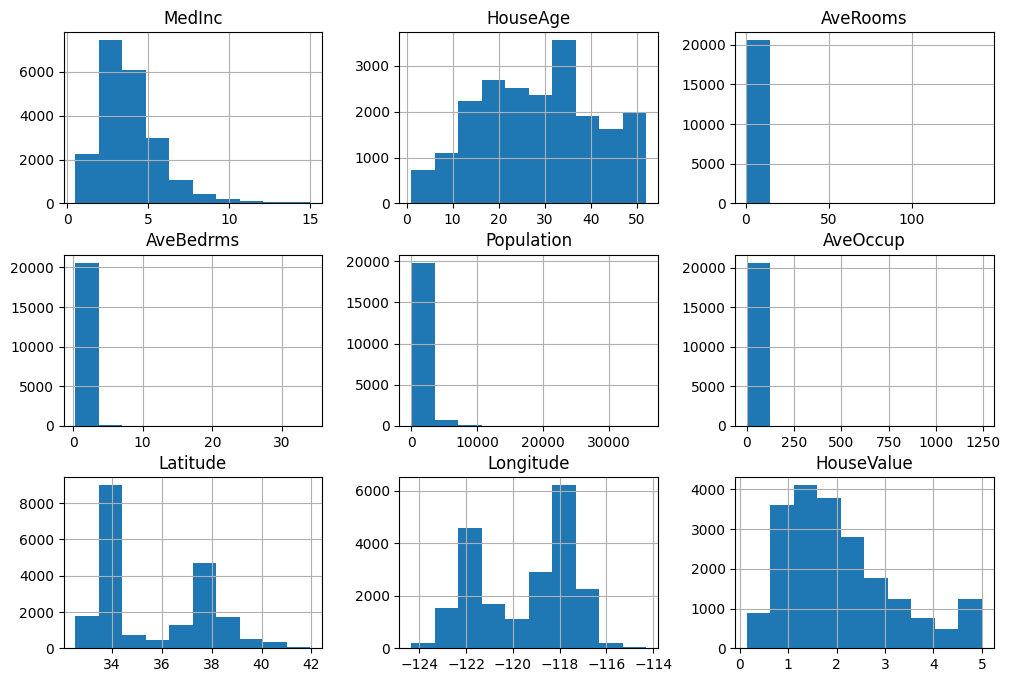

In [ ]:
df.hist(figsize=(12,8))
plt.show()

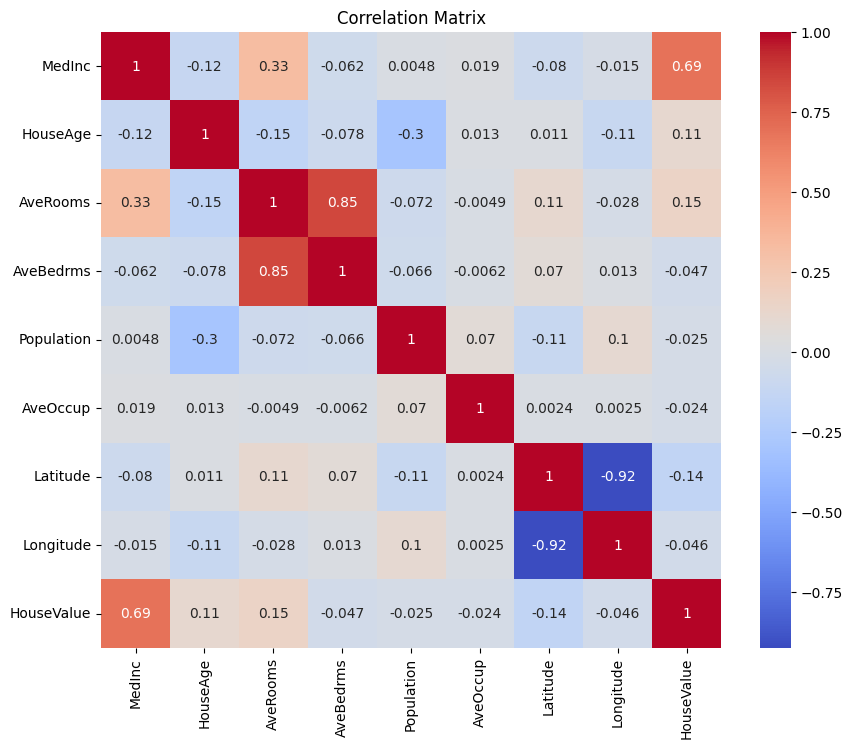

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
print(corr_matrix["HouseValue"].sort_values(ascending=False))

HouseValue    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HouseValue, dtype: float64


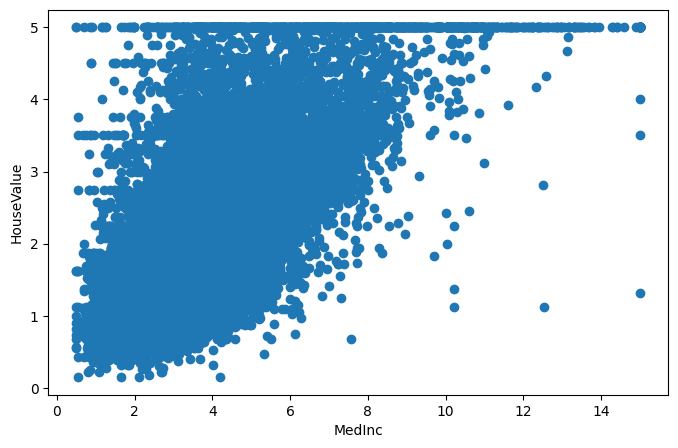

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["MedInc"],
    df["HouseValue"]
)
plt.xlabel("MedInc")
plt.ylabel("HouseValue")
plt.show()

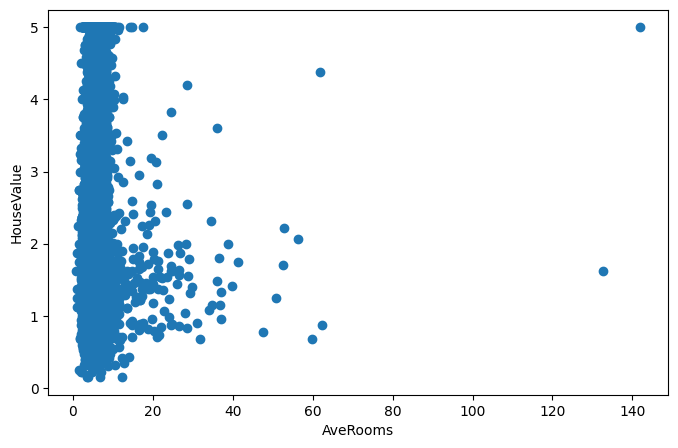

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["AveRooms"], df["HouseValue"])

plt.xlabel("AveRooms")
plt.ylabel("HouseValue")
plt.show()

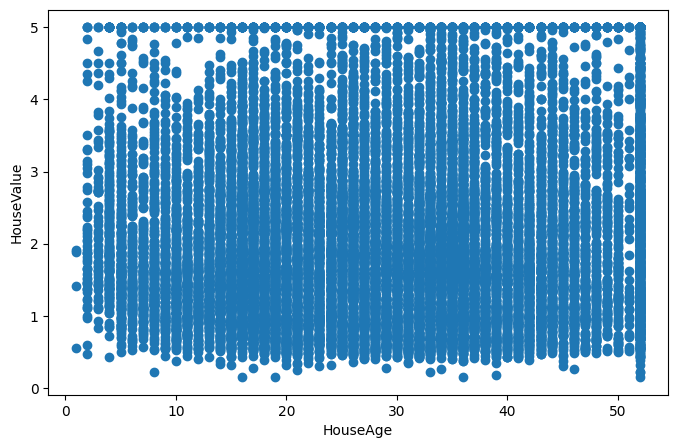

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["HouseAge"], df["HouseValue"])

plt.xlabel("HouseAge")
plt.ylabel("HouseValue")
plt.show()

In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HouseValue,0


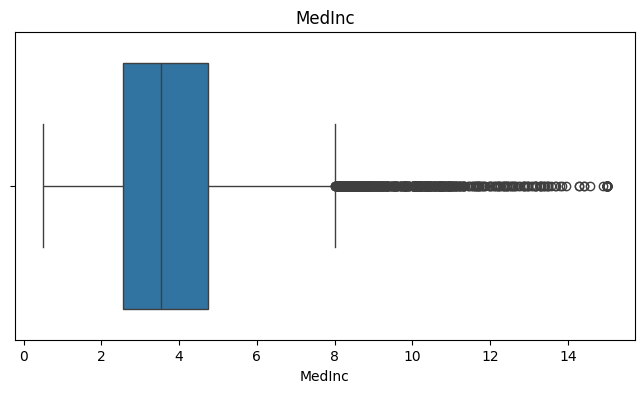

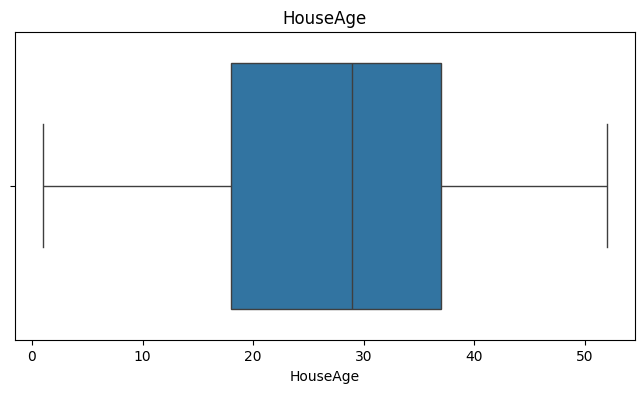

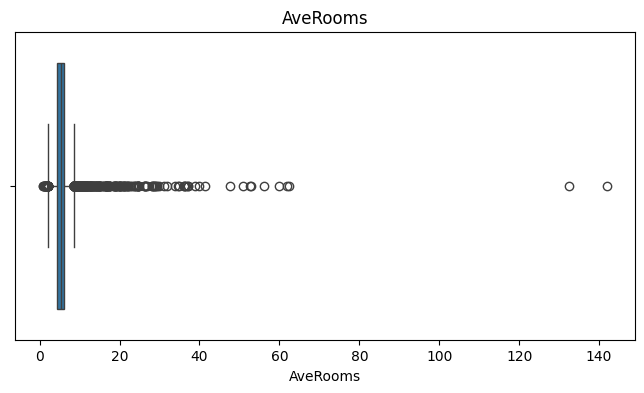

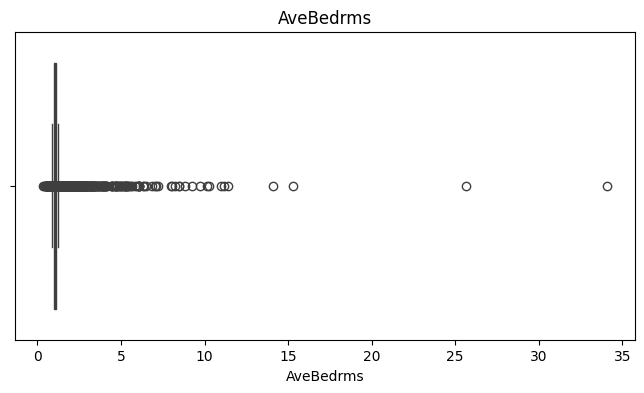

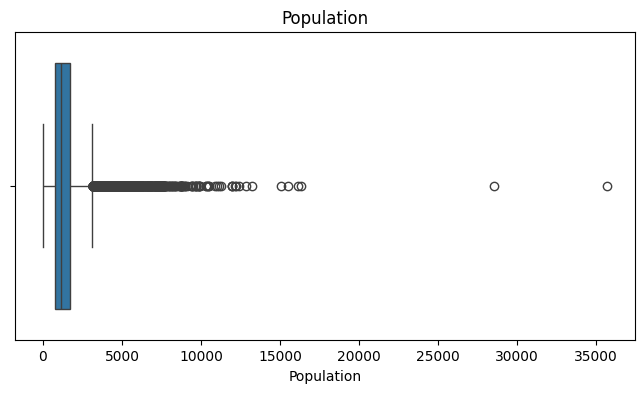

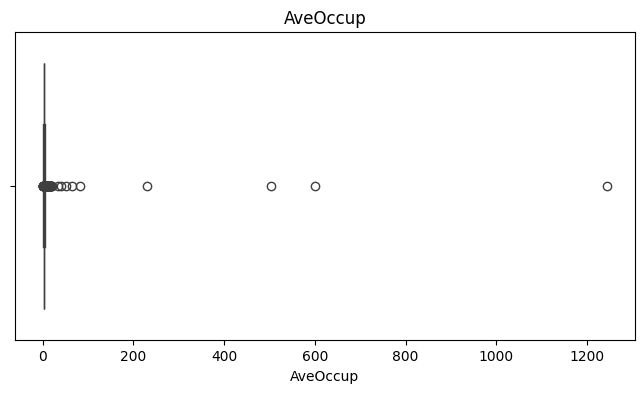

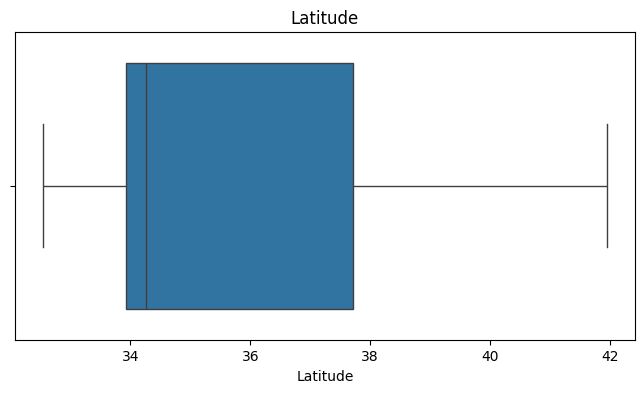

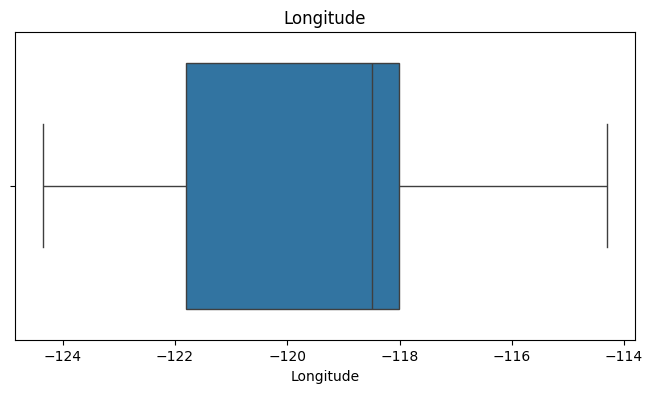

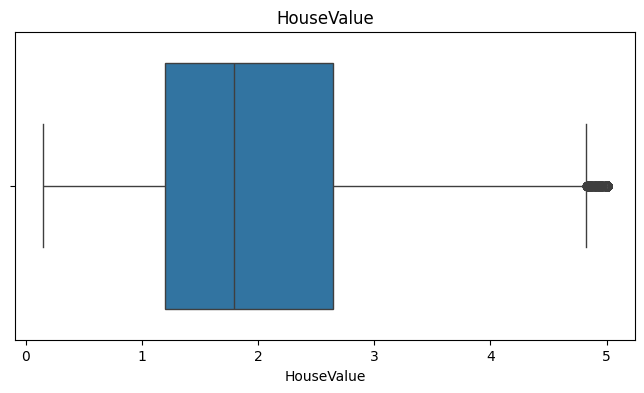

In [ ]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
Q1 = df["AveOccup"].quantile(0.25)
Q3 = df["AveOccup"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["AveOccup"] < lower) |
    (df["AveOccup"] > upper)
]

print(len(outliers))

711


In [ ]:
for col in ["AveRooms","AveBedrms","Population","AveOccup"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col)
    print("Outliers:", len(outliers))
    print()

AveRooms
Outliers: 511

AveBedrms
Outliers: 1424

Population
Outliers: 1196

AveOccup
Outliers: 711



In [ ]:
df[["AveRooms","AveBedrms","Population","AveOccup"]].sort_values(
    by="AveOccup",
    ascending=False
).head(10)

,AveRooms,AveBedrms,Population,AveOccup
19006,3.166667,0.833333,7460.0,1243.333333
3364,5.142857,1.142857,4198.0,599.714286
16669,9.076923,1.307692,6532.0,502.461538
13034,8.275862,1.517241,6675.0,230.172414
9172,5.123810,0.933333,8733.0,83.171429
12104,7.600000,0.950000,1275.0,63.750000
16420,5.366667,0.900000,1542.0,51.400000
8874,7.285714,1.214286,1154.0,41.214286
13366,5.258824,1.117647,2886.0,33.952941
5986,4.500000,1.206349,2688.0,21.333333


In [ ]:
df[["AveRooms","AveBedrms","Population","AveOccup"]].sort_values(
    by="AveRooms",
    ascending=False
).head(10)

,AveRooms,AveBedrms,Population,AveOccup
1914,141.909091,25.636364,30.0,2.727273
1979,132.533333,34.066667,36.0,2.400000
12447,62.422222,14.111111,83.0,1.844444
1913,61.812500,11.000000,112.0,2.333333
11862,59.875000,15.312500,28.0,1.750000
1912,56.269231,10.153846,54.0,2.076923
9676,52.848214,11.410714,265.0,2.366071
11707,52.690476,8.857143,98.0,2.333333
2395,50.837838,10.270270,64.0,1.729730
1240,47.515152,11.181818,82.0,2.484848


In [ ]:
df[["AveRooms","AveBedrms","Population","AveOccup"]].sort_values(
    by="AveBedrms",
    ascending=False
).head(10)

,AveRooms,AveBedrms,Population,AveOccup
1979,132.533333,34.066667,36.0,2.400000
1914,141.909091,25.636364,30.0,2.727273
11862,59.875000,15.312500,28.0,1.750000
12447,62.422222,14.111111,83.0,1.844444
9676,52.848214,11.410714,265.0,2.366071
1240,47.515152,11.181818,82.0,2.484848
1913,61.812500,11.000000,112.0,2.333333
2395,50.837838,10.270270,64.0,1.729730
1912,56.269231,10.153846,54.0,2.076923
1102,31.777778,9.703704,47.0,1.740741


In [ ]:
X = df.drop("HouseValue", axis=1)
y = df["HouseValue"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
sclar = StandardScaler()
X_train_scaled = sclar.fit_transform(X_train)
X_test_sclaed = sclar.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_sclaed)

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.5332001304956565


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.5558915986952442


In [ ]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.7455813830127763


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.575787706032451


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.5332001304956565
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R2  : 0.575787706032451


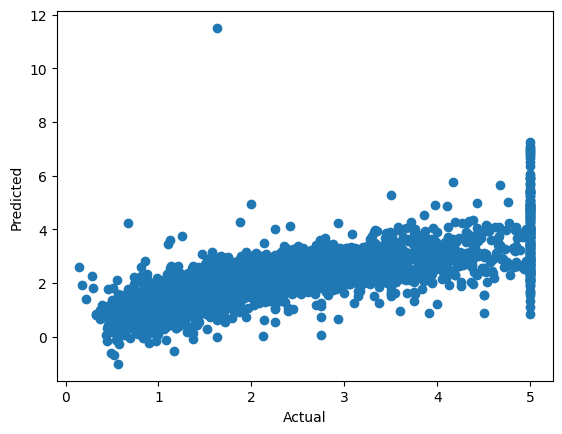

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

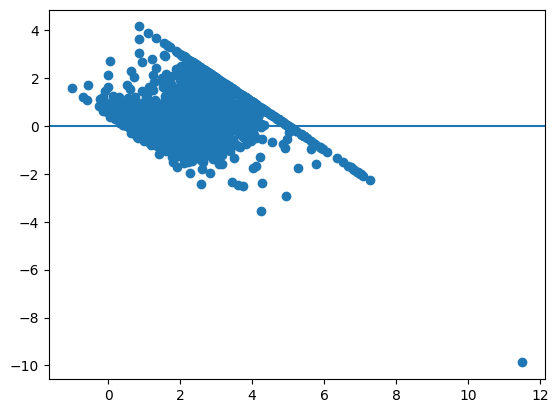

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.show()

In [ ]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

,Feature,Coefficient
0,MedInc,0.854383
1,HouseAge,0.122546
2,AveRooms,-0.294410
3,AveBedrms,0.339259
4,Population,-0.002308
5,AveOccup,-0.040829
6,Latitude,-0.896929
7,Longitude,-0.869842


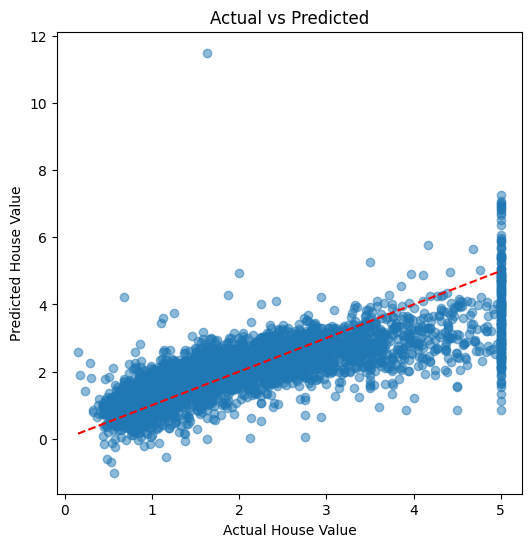

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

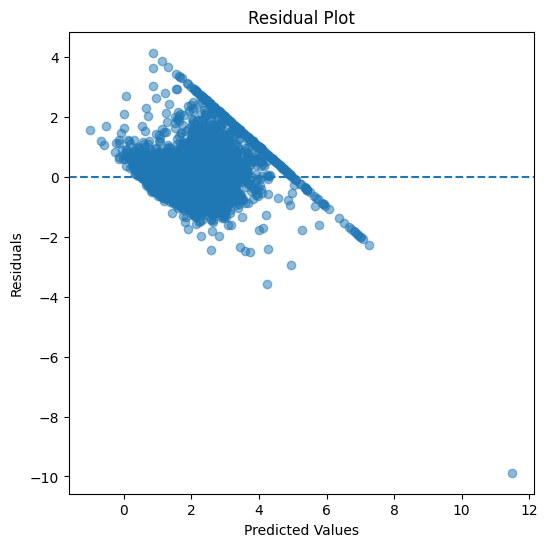

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df)

      Feature  Coefficient
0      MedInc     0.854383
3   AveBedrms     0.339259
1    HouseAge     0.122546
4  Population    -0.002308
5    AveOccup    -0.040829
2    AveRooms    -0.294410
7   Longitude    -0.869842
6    Latitude    -0.896929


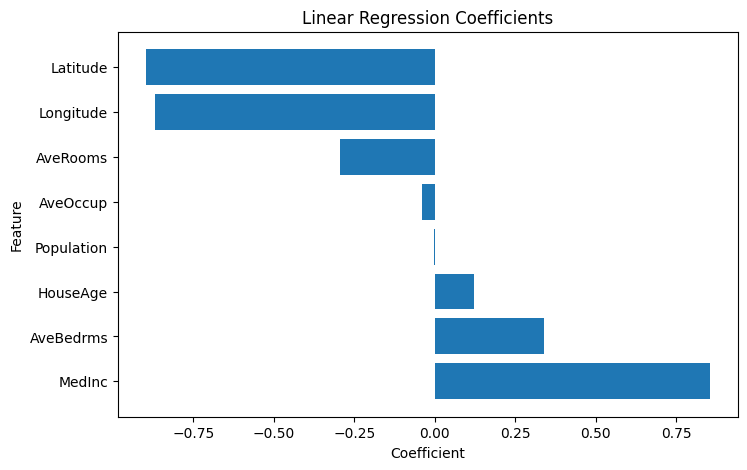

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")

plt.show()

In [ ]:
import numpy as np

X2 = X.copy()
y2 = y.copy()

X2["Population"] = np.log1p(X2["Population"])
X2["AveOccup"] = np.log1p(X2["AveOccup"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [ ]:
sclar = StandardScaler()
X_train_scaled = sclar.fit_transform(X_train)
X_test_sclaed = sclar.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_sclaed)

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.4995100954629051


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.4856620979172309


In [ ]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.6968946103373386


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.4995100954629051
MSE : 0.4856620979172309
RMSE: 0.6968946103373386
R2  : 0.6293812802097964


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)

print("MAPE:", mape)
print("Pseudo Accuracy:", (1 - mape) * 100)

MAPE: 0.3020598171044775
Pseudo Accuracy: 69.79401828955226
